# MOUNT GOOGLE DRIVE

In [44]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# IMPORTS

In [45]:
import os
import re
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from glob import glob
from scipy.ndimage import map_coordinates, gaussian_filter

# PATHS (EDIT THESE ONLY)

In [46]:
path = "/content/drive/MyDrive/Project work/Dataset/lgg-mri-segmentation/lgg_structured"
print("Base path exists :", os.path.exists(path))

TRAIN_IMG_DIR  = os.path.join(path, "train/images")
TRAIN_MASK_DIR = os.path.join(path, "train/masks")
print("Train images exists :", os.path.exists(TRAIN_IMG_DIR))
print("Train masks  exists :", os.path.exists(TRAIN_MASK_DIR))

VAL_IMG_DIR    = os.path.join(path, "val/images")
VAL_MASK_DIR   = os.path.join(path, "val/masks")
print("Val   images exists :", os.path.exists(VAL_IMG_DIR))
print("Val   masks  exists :", os.path.exists(VAL_MASK_DIR))

TEST_IMG_DIR   = os.path.join(path, "test/images")
TEST_MASK_DIR  = os.path.join(path, "test/masks")
print("Test  images exists :", os.path.exists(TEST_IMG_DIR))
print("Test  masks  exists :", os.path.exists(TEST_MASK_DIR))

MODEL_SAVE_PATH = "/content/drive/MyDrive/Project work/models/Segmentation/attention_resunet.keras"

Base path exists : True
Train images exists : True
Train masks  exists : True
Val   images exists : True
Val   masks  exists : True
Test  images exists : True
Test  masks  exists : True


# CONFIG

In [47]:
IMG_SIZE    = 320
BATCH_SIZE  = 8
SEED        = 42
EPOCHS      = 80
TARGET_DICE = 0.80
GRAPHS      = []

# DATA LOADING

In [48]:
def numeric_sort(filepath):
    nums = re.findall(r"\d+", os.path.basename(filepath))
    return [int(n) for n in nums]

train_images = sorted(glob(os.path.join(TRAIN_IMG_DIR,  "*")), key=numeric_sort)
train_masks  = sorted(glob(os.path.join(TRAIN_MASK_DIR, "*")), key=numeric_sort)

val_images   = sorted(glob(os.path.join(VAL_IMG_DIR,    "*")), key=numeric_sort)
val_masks    = sorted(glob(os.path.join(VAL_MASK_DIR,   "*")), key=numeric_sort)

test_images  = sorted(glob(os.path.join(TEST_IMG_DIR,   "*")), key=numeric_sort)
test_masks   = sorted(glob(os.path.join(TEST_MASK_DIR,  "*")), key=numeric_sort)

print(f"Train : {len(train_images)} images | {len(train_masks)} masks")
print(f"Val   : {len(val_images)} images | {len(val_masks)} masks")
print(f"Test  : {len(test_images)} images | {len(test_masks)} masks")

Train : 3133 images | 3133 masks
Val   : 409 images | 409 masks
Test  : 387 images | 387 masks


# CRITICAL VERIFICATION

In [49]:
print("\n--- Image/Mask Pair Check ---")
for i in range(min(5, len(train_images))):
    img_name  = os.path.basename(train_images[i])
    mask_name = os.path.basename(train_masks[i])
    match = "OK" if img_name.replace(".tif", "") == mask_name.replace("_mask.tif", "") else "MISMATCH"
    print(f"  {img_name}  |  {mask_name}  ->  {match}")
print("-----------------------------\n")


--- Image/Mask Pair Check ---
  TCGA_FG_A4MT_20020212_1.tif  |  TCGA_FG_A4MT_20020212_1_mask.tif  ->  OK
  TCGA_FG_A4MT_20020212_2.tif  |  TCGA_FG_A4MT_20020212_2_mask.tif  ->  OK
  TCGA_FG_A4MT_20020212_3.tif  |  TCGA_FG_A4MT_20020212_3_mask.tif  ->  OK
  TCGA_FG_A4MT_20020212_4.tif  |  TCGA_FG_A4MT_20020212_4_mask.tif  ->  OK
  TCGA_FG_A4MT_20020212_5.tif  |  TCGA_FG_A4MT_20020212_5_mask.tif  ->  OK
-----------------------------



# PREPROCESSING

In [50]:
def load_image(img_path):
    img = cv2.imread(img_path.numpy().decode(), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

def load_mask(mask_path):
    mask = cv2.imread(mask_path.numpy().decode(), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)
    return mask

def parse_sample(img_path, mask_path):
    img  = tf.py_function(load_image, [img_path], tf.float32)
    mask = tf.py_function(load_mask,  [mask_path], tf.float32)
    img.set_shape( [IMG_SIZE, IMG_SIZE, 1])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

# AUGMENTATION

In [51]:
def elastic_deform(img, mask):
    img_np  = img.numpy().squeeze()
    mask_np = mask.numpy().squeeze()
    shape   = img_np.shape
    alpha   = shape[0] * 1.5
    sigma   = shape[0] * 0.07
    dx = gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
    x, y    = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices = (np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1)))
    img_d   = map_coordinates(img_np,  indices, order=1).reshape(shape)
    mask_d  = map_coordinates(mask_np, indices, order=0).reshape(shape)
    return (
        np.expand_dims(img_d.astype(np.float32),  axis=-1),
        np.expand_dims(mask_d.astype(np.float32), axis=-1)
    )

def augment_sample(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    k    = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img  = tf.image.rot90(img,  k)
    mask = tf.image.rot90(mask, k)
    if tf.random.uniform(()) > 0.5:
        scale = tf.random.uniform((), 0.85, 1.15)
        new_h = tf.cast(IMG_SIZE * scale, tf.int32)
        new_w = tf.cast(IMG_SIZE * scale, tf.int32)
        img   = tf.image.resize(img,  [new_h, new_w])
        mask  = tf.image.resize(mask, [new_h, new_w], method="nearest")
        img   = tf.image.resize_with_crop_or_pad(img,  IMG_SIZE, IMG_SIZE)
        mask  = tf.image.resize_with_crop_or_pad(mask, IMG_SIZE, IMG_SIZE)
    if tf.random.uniform(()) > 0.6:
        img, mask = tf.py_function(elastic_deform, [img, mask], [tf.float32, tf.float32])
        img.set_shape( [IMG_SIZE, IMG_SIZE, 1])
        mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    if tf.random.uniform(()) > 0.5:
        noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.02)
        img   = tf.clip_by_value(img + noise, 0.0, 1.0)
    img  = tf.image.random_brightness(img, max_delta=0.1)
    img  = tf.clip_by_value(img, 0.0, 1.0)
    img  = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img  = tf.clip_by_value(img, 0.0, 1.0)
    mask = tf.cast(mask > 0.5, tf.float32)
    return img, mask

# DATA PIPELINE

In [52]:
AUTOTUNE = tf.data.AUTOTUNE

def triple_mask(img, mask):
    return img, (mask, mask, mask)

train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_masks))
train_ds = train_ds.shuffle(len(train_images), seed=SEED)
train_ds = train_ds.map(parse_sample,   num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(augment_sample, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(triple_mask,    num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_masks))
val_ds = val_ds.map(parse_sample,  num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(triple_mask,   num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_masks))
test_ds = test_ds.map(parse_sample, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Datasets ready.")

Datasets ready.


# VERIFY SAMPLES

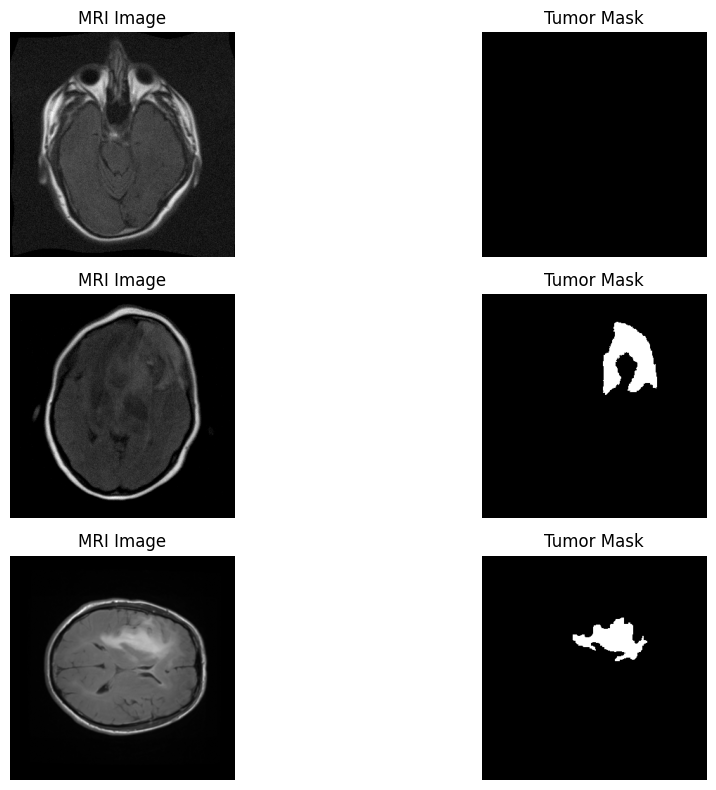

In [53]:
plt.figure(figsize=(12, 8))
for imgs, (masks, _, _) in train_ds.take(1):
    for i in range(3):
        plt.subplot(3, 2, i * 2 + 1)
        plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
        plt.title("MRI Image")
        plt.axis("off")
        plt.subplot(3, 2, i * 2 + 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
        plt.title("Tumor Mask")
        plt.axis("off")
plt.tight_layout()
plt.show()

# LOSS AND METRICS

In [54]:
def tversky_index(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1 - y_pred_f))
    fp = tf.reduce_sum((1 - y_true_f) * y_pred_f)
    return (tp + smooth) / (tp + alpha * fn + beta * fp + smooth)

def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    return tf.pow(1.0 - tversky_index(y_true, y_pred), gamma)

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# ATTENTION GATE

In [55]:
def attention_gate(g, x, filters):
    g_conv = tf.keras.layers.Conv2D(filters, 1, padding="same")(g)
    g_conv = tf.keras.layers.BatchNormalization()(g_conv)
    g_conv = tf.keras.layers.UpSampling2D(size=(2, 2))(g_conv)
    x_conv = tf.keras.layers.Conv2D(filters, 1, padding="same")(x)
    x_conv = tf.keras.layers.BatchNormalization()(x_conv)
    combined = tf.keras.layers.Add()([g_conv, x_conv])
    combined = tf.keras.layers.Activation("relu")(combined)
    combined = tf.keras.layers.Conv2D(1, 1, padding="same")(combined)
    combined = tf.keras.layers.Activation("sigmoid")(combined)
    return tf.keras.layers.Multiply()([x, combined])

# BUILD MODEL — ENCODER

In [56]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

x  = tf.keras.layers.Conv2D(32, 3, padding="same")(inputs)
x  = tf.keras.layers.BatchNormalization()(x)
x  = tf.keras.layers.Activation("relu")(x)
x  = tf.keras.layers.Conv2D(32, 3, padding="same")(x)
x  = tf.keras.layers.BatchNormalization()(x)
r1 = tf.keras.layers.Conv2D(32, 1, padding="same")(inputs)
e1 = tf.keras.layers.Add()([x, r1])
e1 = tf.keras.layers.Activation("relu")(e1)
p1 = tf.keras.layers.MaxPooling2D(2)(e1)

x  = tf.keras.layers.Conv2D(64, 3, padding="same")(p1)
x  = tf.keras.layers.BatchNormalization()(x)
x  = tf.keras.layers.Activation("relu")(x)
x  = tf.keras.layers.Conv2D(64, 3, padding="same")(x)
x  = tf.keras.layers.BatchNormalization()(x)
r2 = tf.keras.layers.Conv2D(64, 1, padding="same")(p1)
e2 = tf.keras.layers.Add()([x, r2])
e2 = tf.keras.layers.Activation("relu")(e2)
p2 = tf.keras.layers.MaxPooling2D(2)(e2)

x  = tf.keras.layers.Conv2D(128, 3, padding="same")(p2)
x  = tf.keras.layers.BatchNormalization()(x)
x  = tf.keras.layers.Activation("relu")(x)
x  = tf.keras.layers.Conv2D(128, 3, padding="same")(x)
x  = tf.keras.layers.BatchNormalization()(x)
r3 = tf.keras.layers.Conv2D(128, 1, padding="same")(p2)
e3 = tf.keras.layers.Add()([x, r3])
e3 = tf.keras.layers.Activation("relu")(e3)
p3 = tf.keras.layers.MaxPooling2D(2)(e3)

x  = tf.keras.layers.Conv2D(256, 3, padding="same")(p3)
x  = tf.keras.layers.BatchNormalization()(x)
x  = tf.keras.layers.Activation("relu")(x)
x  = tf.keras.layers.Conv2D(256, 3, padding="same")(x)
x  = tf.keras.layers.BatchNormalization()(x)
r4 = tf.keras.layers.Conv2D(256, 1, padding="same")(p3)
e4 = tf.keras.layers.Add()([x, r4])
e4 = tf.keras.layers.Activation("relu")(e4)
p4 = tf.keras.layers.MaxPooling2D(2)(e4)

# BUILD MODEL — BOTTLENECK

In [57]:
b = tf.keras.layers.Conv2D(768, 3, padding="same")(p4)
b = tf.keras.layers.BatchNormalization()(b)
b = tf.keras.layers.Activation("relu")(b)
b = tf.keras.layers.Dropout(0.4)(b)
b = tf.keras.layers.Conv2D(768, 3, padding="same")(b)
b = tf.keras.layers.BatchNormalization()(b)
b = tf.keras.layers.Activation("relu")(b)

# BUILD MODEL — DECODER

In [58]:
a4 = attention_gate(g=b,  x=e4, filters=256)
d1 = tf.keras.layers.Conv2DTranspose(256, 2, strides=2, padding="same")(b)
d1 = tf.keras.layers.Concatenate()([d1, a4])
d1 = tf.keras.layers.Conv2D(256, 3, padding="same")(d1)
d1 = tf.keras.layers.BatchNormalization()(d1)
d1 = tf.keras.layers.Activation("relu")(d1)
d1 = tf.keras.layers.Conv2D(256, 3, padding="same")(d1)
d1 = tf.keras.layers.BatchNormalization()(d1)
d1 = tf.keras.layers.Activation("relu")(d1)

a3 = attention_gate(g=d1, x=e3, filters=128)
d2 = tf.keras.layers.Conv2DTranspose(128, 2, strides=2, padding="same")(d1)
d2 = tf.keras.layers.Concatenate()([d2, a3])
d2 = tf.keras.layers.Conv2D(128, 3, padding="same")(d2)
d2 = tf.keras.layers.BatchNormalization()(d2)
d2 = tf.keras.layers.Activation("relu")(d2)
d2 = tf.keras.layers.Conv2D(128, 3, padding="same")(d2)
d2 = tf.keras.layers.BatchNormalization()(d2)
d2 = tf.keras.layers.Activation("relu")(d2)

d2_up  = tf.keras.layers.UpSampling2D(size=(4, 4))(d2)
d2_out = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", name="d2_out")(d2_up)

a2 = attention_gate(g=d2, x=e2, filters=64)
d3 = tf.keras.layers.Conv2DTranspose(64, 2, strides=2, padding="same")(d2)
d3 = tf.keras.layers.Concatenate()([d3, a2])
d3 = tf.keras.layers.Conv2D(64, 3, padding="same")(d3)
d3 = tf.keras.layers.BatchNormalization()(d3)
d3 = tf.keras.layers.Activation("relu")(d3)
d3 = tf.keras.layers.Conv2D(64, 3, padding="same")(d3)
d3 = tf.keras.layers.BatchNormalization()(d3)
d3 = tf.keras.layers.Activation("relu")(d3)

d3_up  = tf.keras.layers.UpSampling2D(size=(2, 2))(d3)
d3_out = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", name="d3_out")(d3_up)

a1 = attention_gate(g=d3, x=e1, filters=32)
d4 = tf.keras.layers.Conv2DTranspose(32, 2, strides=2, padding="same")(d3)
d4 = tf.keras.layers.Concatenate()([d4, a1])
d4 = tf.keras.layers.Conv2D(32, 3, padding="same")(d4)
d4 = tf.keras.layers.BatchNormalization()(d4)
d4 = tf.keras.layers.Activation("relu")(d4)
d4 = tf.keras.layers.Conv2D(32, 3, padding="same")(d4)
d4 = tf.keras.layers.BatchNormalization()(d4)
d4 = tf.keras.layers.Activation("relu")(d4)

# BUILD MODEL — OUTPUT AND SUMMARY

In [59]:
final_out = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", name="final_out")(d4)

model = tf.keras.Model(
    inputs  = inputs,
    outputs = [d2_out, d3_out, final_out],
    name    = "AttentionResUNet"
)

model.summary()

Model: "AttentionResUNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 320, 320,  │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        128 │ conv2d_102[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_78       │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 320, 320,  │      9,248 │ activation_78[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        128 │ conv2d_103[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 320, 320,  │         64 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 320, 320,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_104[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_79       │ (None, 320, 320,  │          0 │ add_24[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 160, 160,  │          0 │ activation_79[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 160, 160,  │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        256 │ conv2d_105[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_80       │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_106 (Conv2D) │ (None, 160, 160,  │     36,928 │ activation_80[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        256 │ conv2d_106[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 160, 160,  │      2,112 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_25 (Add)        │ (None, 160, 160,  │          0 │ batch_normalizat

 Total params: 11,950,599 (45.59 MB)

 Trainable params: 11,941,767 (45.55 MB)

 Non-trainable params: 8,832 (34.50 KB)

# LEARNING RATE — COSINE DECAY

In [60]:
total_steps  = (len(train_images) // BATCH_SIZE) * EPOCHS
warmup_steps = (len(train_images) // BATCH_SIZE) * 3

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = 1e-4,
    decay_steps           = total_steps - warmup_steps,
    alpha                 = 1e-6
)

# CALLBACKS

In [61]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet_temp.h5",
        monitor="val_final_out_dice_coefficient",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_final_out_dice_coefficient",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

# PHASE 1 — INITIAL TRAINING

In [62]:
print("Phase 1 — Training...")

model.compile(
    optimizer = tf.keras.optimizers.AdamW(lr_schedule, weight_decay=1e-5),
    loss = {
        "d2_out"    : focal_tversky_loss,
        "d3_out"    : focal_tversky_loss,
        "final_out" : focal_tversky_loss
    },
    loss_weights = {
        "d2_out"    : 0.2,
        "d3_out"    : 0.3,
        "final_out" : 0.5
    },
    metrics = {
        "final_out" : [dice_coefficient, iou_score]
    }
)

hist_phase1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks
)

model.load_weights("best_unet_temp.h5")
GRAPHS.append(hist_phase1)

Phase 1 — Training...
Epoch 1/80
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - d2_out_loss: 0.8976 - d3_out_loss: 0.9206 - final_out_dice_coefficient: 0.0416 - final_out_iou_score: 0.0215 - final_out_loss: 0.9496 - loss: 0.9305
Epoch 1: val_final_out_dice_coefficient improved from -inf to 0.04357, saving model to best_unet_temp.h5


392/392 ━━━━━━━━━━━━━━━━━━━━ 115s 170ms/step - d2_out_loss: 0.8975 - d3_out_loss: 0.9205 - final_out_dice_coefficient: 0.0416 - final_out_iou_score: 0.0215 - final_out_loss: 0.9496 - loss: 0.9304 - val_d2_out_loss: 0.9892 - val_d3_out_loss: 0.9765 - val_final_out_dice_coefficient: 0.0436 - val_final_out_iou_score: 0.0241 - val_final_out_loss: 0.9511 - val_loss: 0.9657
Epoch 2/80
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - d2_out_loss: 0.8117 - d3_out_loss: 0.8512 - final_out_dice_coefficient: 0.0615 - final_out_iou_score: 0.0322 - final_out_loss: 0.9267 - loss: 0.8810
Epoch 2: val_final_out_dice_coefficient improved from 0.04357 to 0.06491, saving model to best_unet_temp.h5


392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - d2_out_loss: 0.8115 - d3_out_loss: 0.8510 - final_out_dice_coefficient: 0.0616 - final_out_iou_score: 0.0322 - final_out_loss: 0.9267 - loss: 0.8809 - val_d2_out_loss: 0.8503 - val_d3_out_loss: 0.8697 - val_final_out_dice_coefficient: 0.0649 - val_final_out_iou_score: 0.0372 - val_final_out_loss: 0.9274 - val_loss: 0.8928
Epoch 3/80
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - d2_out_loss: 0.6873 - d3_out_loss: 0.7367 - final_out_dice_coefficient: 0.0876 - final_out_iou_score: 0.0468 - final_out_loss: 0.8985 - loss: 0.8077
Epoch 3: val_final_out_dice_coefficient did not improve from 0.06491
392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - d2_out_loss: 0.6871 - d3_out_loss: 0.7365 - final_out_dice_coefficient: 0.0877 - final_out_iou_score: 0.0469 - final_out_loss: 0.8984 - loss: 0.8076 - val_d2_out_loss: 0.9160 - val_d3_out_loss: 0.9210 - val_final_out_dice_coefficient: 0.0489 - val_final_out_iou_score: 0.0270 - val_final_out_loss: 0.9499 - val_

392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - d2_out_loss: 0.6140 - d3_out_loss: 0.6428 - final_out_dice_coefficient: 0.1397 - final_out_iou_score: 0.0774 - final_out_loss: 0.8431 - loss: 0.7372 - val_d2_out_loss: 0.8512 - val_d3_out_loss: 0.8544 - val_final_out_dice_coefficient: 0.0964 - val_final_out_iou_score: 0.0588 - val_final_out_loss: 0.8979 - val_loss: 0.8734
Epoch 5/80
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - d2_out_loss: 0.5827 - d3_out_loss: 0.5988 - final_out_dice_coefficient: 0.2036 - final_out_iou_score: 0.1185 - final_out_loss: 0.7820 - loss: 0.6872
Epoch 5: val_final_out_dice_coefficient improved from 0.09636 to 0.13679, saving model to best_unet_temp.h5


392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - d2_out_loss: 0.5826 - d3_out_loss: 0.5987 - final_out_dice_coefficient: 0.2037 - final_out_iou_score: 0.1186 - final_out_loss: 0.7819 - loss: 0.6871 - val_d2_out_loss: 0.8217 - val_d3_out_loss: 0.8221 - val_final_out_dice_coefficient: 0.1368 - val_final_out_iou_score: 0.0899 - val_final_out_loss: 0.8649 - val_loss: 0.8407
Epoch 6/80
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - d2_out_loss: 0.5748 - d3_out_loss: 0.5822 - final_out_dice_coefficient: 0.2775 - final_out_iou_score: 0.1719 - final_out_loss: 0.7181 - loss: 0.6487
Epoch 6: val_final_out_dice_coefficient improved from 0.13679 to 0.17282, saving model to best_unet_temp.h5


...

392/392 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - d2_out_loss: 0.4736 - d3_out_loss: 0.4668 - final_out_dice_coefficient: 0.5512 - final_out_iou_score: 0.4113 - final_out_loss: 0.4923 - loss: 0.4809 - val_d2_out_loss: 0.7783 - val_d3_out_loss: 0.7710 - val_final_out_dice_coefficient: 0.2420 - val_final_out_iou_score: 0.1958 - val_final_out_loss: 0.7773 - val_loss: 0.7718
Epoch 12/80
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - d2_out_loss: 0.4648 - d3_out_loss: 0.4568 - final_out_dice_coefficient: 0.5716 - final_out_iou_score: 0.4398 - final_out_loss: 0.4768 - loss: 0.4684
Epoch 12: val_final_out_dice_coefficient improved from 0.24201 to 0.24460, saving model to best_unet_temp.h5


392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - d2_out_loss: 0.4648 - d3_out_loss: 0.4568 - final_out_dice_coefficient: 0.5716 - final_out_iou_score: 0.4398 - final_out_loss: 0.4768 - loss: 0.4684 - val_d2_out_loss: 0.7754 - val_d3_out_loss: 0.7702 - val_final_out_dice_coefficient: 0.2446 - val_final_out_iou_score: 0.1929 - val_final_out_loss: 0.7757 - val_loss: 0.7702
Epoch 13/80
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - d2_out_loss: 0.4569 - d3_out_loss: 0.4480 - final_out_dice_coefficient: 0.5937 - final_out_iou_score: 0.4614 - final_out_loss: 0.4607 - loss: 0.4561
Epoch 13: val_final_out_dice_coefficient did not improve from 0.24460
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - d2_out_loss: 0.4570 - d3_out_loss: 0.4481 - final_out_dice_coefficient: 0.5936 - final_out_iou_score: 0.4613 - final_out_loss: 0.4608 - loss: 0.4562 - val_d2_out_loss: 0.7798 - val_d3_out_loss: 0.7755 - val_final_out_dice_coefficient: 0.2381 - val_final_out_iou_score: 0.1859 - val_final_out_loss: 0.7781 - va

392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - d2_out_loss: 0.4852 - d3_out_loss: 0.4725 - final_out_dice_coefficient: 0.5805 - final_out_iou_score: 0.4481 - final_out_loss: 0.4770 - loss: 0.4773 - val_d2_out_loss: 0.7539 - val_d3_out_loss: 0.7465 - val_final_out_dice_coefficient: 0.2704 - val_final_out_iou_score: 0.2196 - val_final_out_loss: 0.7477 - val_loss: 0.7443
Epoch 17/80
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - d2_out_loss: 0.4538 - d3_out_loss: 0.4397 - final_out_dice_coefficient: 0.6123 - final_out_iou_score: 0.4806 - final_out_loss: 0.4448 - loss: 0.4451
Epoch 17: val_final_out_dice_coefficient did not improve from 0.27036
392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - d2_out_loss: 0.4538 - d3_out_loss: 0.4396 - final_out_dice_coefficient: 0.6123 - final_out_iou_score: 0.4806 - final_out_loss: 0.4447 - loss: 0.4450 - val_d2_out_loss: 0.7722 - val_d3_out_loss: 0.7699 - val_final_out_dice_coefficient: 0.2456 - val_final_out_iou_score: 0.1874 - val_final_out_loss: 0.7710 - va

392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - d2_out_loss: 0.4378 - d3_out_loss: 0.4241 - final_out_dice_coefficient: 0.6361 - final_out_iou_score: 0.5097 - final_out_loss: 0.4246 - loss: 0.4271 - val_d2_out_loss: 0.7480 - val_d3_out_loss: 0.7425 - val_final_out_dice_coefficient: 0.2771 - val_final_out_iou_score: 0.2231 - val_final_out_loss: 0.7424 - val_loss: 0.7392
Epoch 21/80
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - d2_out_loss: 0.4002 - d3_out_loss: 0.3861 - final_out_dice_coefficient: 0.6796 - final_out_iou_score: 0.5519 - final_out_loss: 0.3853 - loss: 0.3885
Epoch 21: val_final_out_dice_coefficient did not improve from 0.27711
392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - d2_out_loss: 0.4002 - d3_out_loss: 0.3861 - final_out_dice_coefficient: 0.6796 - final_out_iou_score: 0.5519 - final_out_loss: 0.3854 - loss: 0.3886 - val_d2_out_loss: 0.8022 - val_d3_out_loss: 0.8063 - val_final_out_dice_coefficient: 0.2257 - val_final_out_iou_score: 0.1804 - val_final_out_loss: 0.8085 - val

392/392 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - d2_out_loss: 0.4384 - d3_out_loss: 0.4276 - final_out_dice_coefficient: 0.6373 - final_out_iou_score: 0.5112 - final_out_loss: 0.4269 - loss: 0.4294 - val_d2_out_loss: 0.7510 - val_d3_out_loss: 0.7468 - val_final_out_dice_coefficient: 0.2910 - val_final_out_iou_score: 0.2366 - val_final_out_loss: 0.7461 - val_loss: 0.7430
Epoch 23/80
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - d2_out_loss: 0.4216 - d3_out_loss: 0.4093 - final_out_dice_coefficient: 0.6578 - final_out_iou_score: 0.5300 - final_out_loss: 0.4080 - loss: 0.4111
Epoch 23: val_final_out_dice_coefficient did not improve from 0.29104
392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - d2_out_loss: 0.4215 - d3_out_loss: 0.4093 - final_out_dice_coefficient: 0.6578 - final_out_iou_score: 0.5300 - final_out_loss: 0.4080 - loss: 0.4111 - val_d2_out_loss: 0.8189 - val_d3_out_loss: 0.8170 - val_final_out_dice_coefficient: 0.1927 - val_final_out_iou_score: 0.1399 - val_final_out_loss: 0.8179 - va

# PHASE 2 — FINE TUNE

In [63]:
best_dice = max(hist_phase1.history["val_final_out_dice_coefficient"])
print(f"Best Val Dice : {best_dice:.4f}")

if best_dice < TARGET_DICE:
    print("Dice below target — Running Phase 2...")
    model.compile(
        optimizer = tf.keras.optimizers.AdamW(1e-5, weight_decay=1e-5),
        loss = {
            "d2_out"    : focal_tversky_loss,
            "d3_out"    : focal_tversky_loss,
            "final_out" : focal_tversky_loss
        },
        loss_weights = {
            "d2_out"    : 0.2,
            "d3_out"    : 0.3,
            "final_out" : 0.5
        },
        metrics = {
            "final_out" : [dice_coefficient, iou_score]
        }
    )
    hist_phase2 = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = 20,
        callbacks       = callbacks
    )
    model.load_weights("best_unet_temp.h5")
    GRAPHS.append(hist_phase2)
else:
    print(f"Dice >= {TARGET_DICE} — Skipping Phase 2")

Best Val Dice : 0.2910
Dice below target — Running Phase 2...
Epoch 1/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - d2_out_loss: 0.4044 - d3_out_loss: 0.3889 - final_out_dice_coefficient: 0.6819 - final_out_iou_score: 0.5596 - final_out_loss: 0.3854 - loss: 0.3902
Epoch 1: val_final_out_dice_coefficient did not improve from 0.29104
392/392 ━━━━━━━━━━━━━━━━━━━━ 108s 168ms/step - d2_out_loss: 0.4044 - d3_out_loss: 0.3889 - final_out_dice_coefficient: 0.6819 - final_out_iou_score: 0.5596 - final_out_loss: 0.3854 - loss: 0.3902 - val_d2_out_loss: 0.7488 - val_d3_out_loss: 0.7447 - val_final_out_dice_coefficient: 0.2765 - val_final_out_iou_score: 0.2219 - val_final_out_loss: 0.7447 - val_loss: 0.7411
Epoch 2/20
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - d2_out_loss: 0.3800 - d3_out_loss: 0.3653 - final_out_dice_coefficient: 0.7045 - final_out_iou_score: 0.5778 - final_out_loss: 0.3628 - loss: 0.3670
Epoch 2: val_final_out_dice_coefficient did not improve from 0.29104
392/392 ━━━━━━━━━━━━

392/392 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - d2_out_loss: 0.3814 - d3_out_loss: 0.3651 - final_out_dice_coefficient: 0.7029 - final_out_iou_score: 0.5838 - final_out_loss: 0.3622 - loss: 0.3669 - val_d2_out_loss: 0.7356 - val_d3_out_loss: 0.7294 - val_final_out_dice_coefficient: 0.2933 - val_final_out_iou_score: 0.2397 - val_final_out_loss: 0.7281 - val_loss: 0.7254
Epoch 11/20
391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - d2_out_loss: 0.3659 - d3_out_loss: 0.3480 - final_out_dice_coefficient: 0.7192 - final_out_iou_score: 0.6013 - final_out_loss: 0.3448 - loss: 0.3500
Epoch 11: val_final_out_dice_coefficient did not improve from 0.29334
392/392 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - d2_out_loss: 0.3659 - d3_out_loss: 0.3479 - final_out_dice_coefficient: 0.7192 - final_out_iou_score: 0.6013 - final_out_loss: 0.3448 - loss: 0.3499 - val_d2_out_loss: 0.7425 - val_d3_out_loss: 0.7397 - val_final_out_dice_coefficient: 0.2824 - val_final_out_iou_score: 0.2302 - val_final_out_loss: 0.7404 - val

# GRAPH

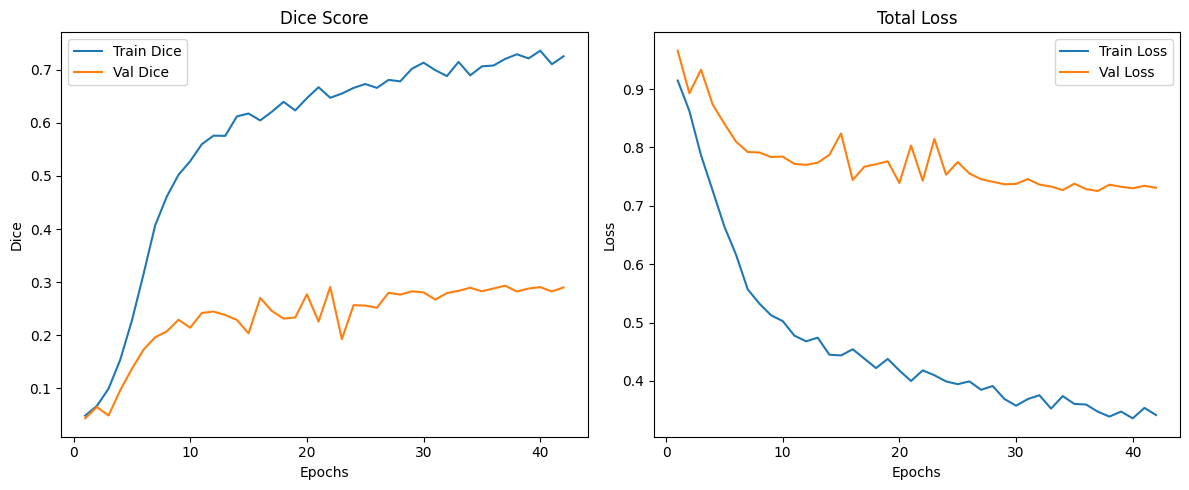

In [64]:
dice_train = []
dice_val   = []
loss_train = []
loss_val   = []

for h in GRAPHS:
    dice_train += h.history["final_out_dice_coefficient"]
    dice_val   += h.history["val_final_out_dice_coefficient"]
    loss_train += h.history["loss"]
    loss_val   += h.history["val_loss"]

epochs_range = range(1, len(dice_train) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, dice_train, label="Train Dice")
plt.plot(epochs_range, dice_val,   label="Val Dice")
plt.title("Dice Score")
plt.xlabel("Epochs")
plt.ylabel("Dice")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_train, label="Train Loss")
plt.plot(epochs_range, loss_val,   label="Val Loss")
plt.title("Total Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# EVALUATE

In [66]:
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_masks))
test_ds = test_ds.map(parse_sample, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(triple_mask, num_parallel_calls=AUTOTUNE)  # ADD THIS
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [67]:
print("Evaluating on Test Set...")
results = model.evaluate(test_ds)
print("\nTest results printed above.")
print("Check val_final_out_dice_coefficient for Dice score.")

Evaluating on Test Set...
49/49 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - d2_out_loss: 0.6837 - d3_out_loss: 0.6692 - final_out_dice_coefficient: 0.3590 - final_out_iou_score: 0.3065 - final_out_loss: 0.6680 - loss: 0.6713

Test results printed above.
Check val_final_out_dice_coefficient for Dice score.


# TEST TIME AUGMENTATION

In [68]:
def predict_with_tta(model, img_batch):
    pred_orig  = model.predict(img_batch,                            verbose=0)[2]
    pred_hflip = model.predict(tf.image.flip_left_right(img_batch), verbose=0)[2]
    pred_vflip = model.predict(tf.image.flip_up_down(img_batch),    verbose=0)[2]
    pred_hflip = tf.image.flip_left_right(pred_hflip).numpy()
    pred_vflip = tf.image.flip_up_down(pred_vflip).numpy()
    return (pred_orig + pred_hflip + pred_vflip) / 3.0

# PREDICTION VISUALIZATION

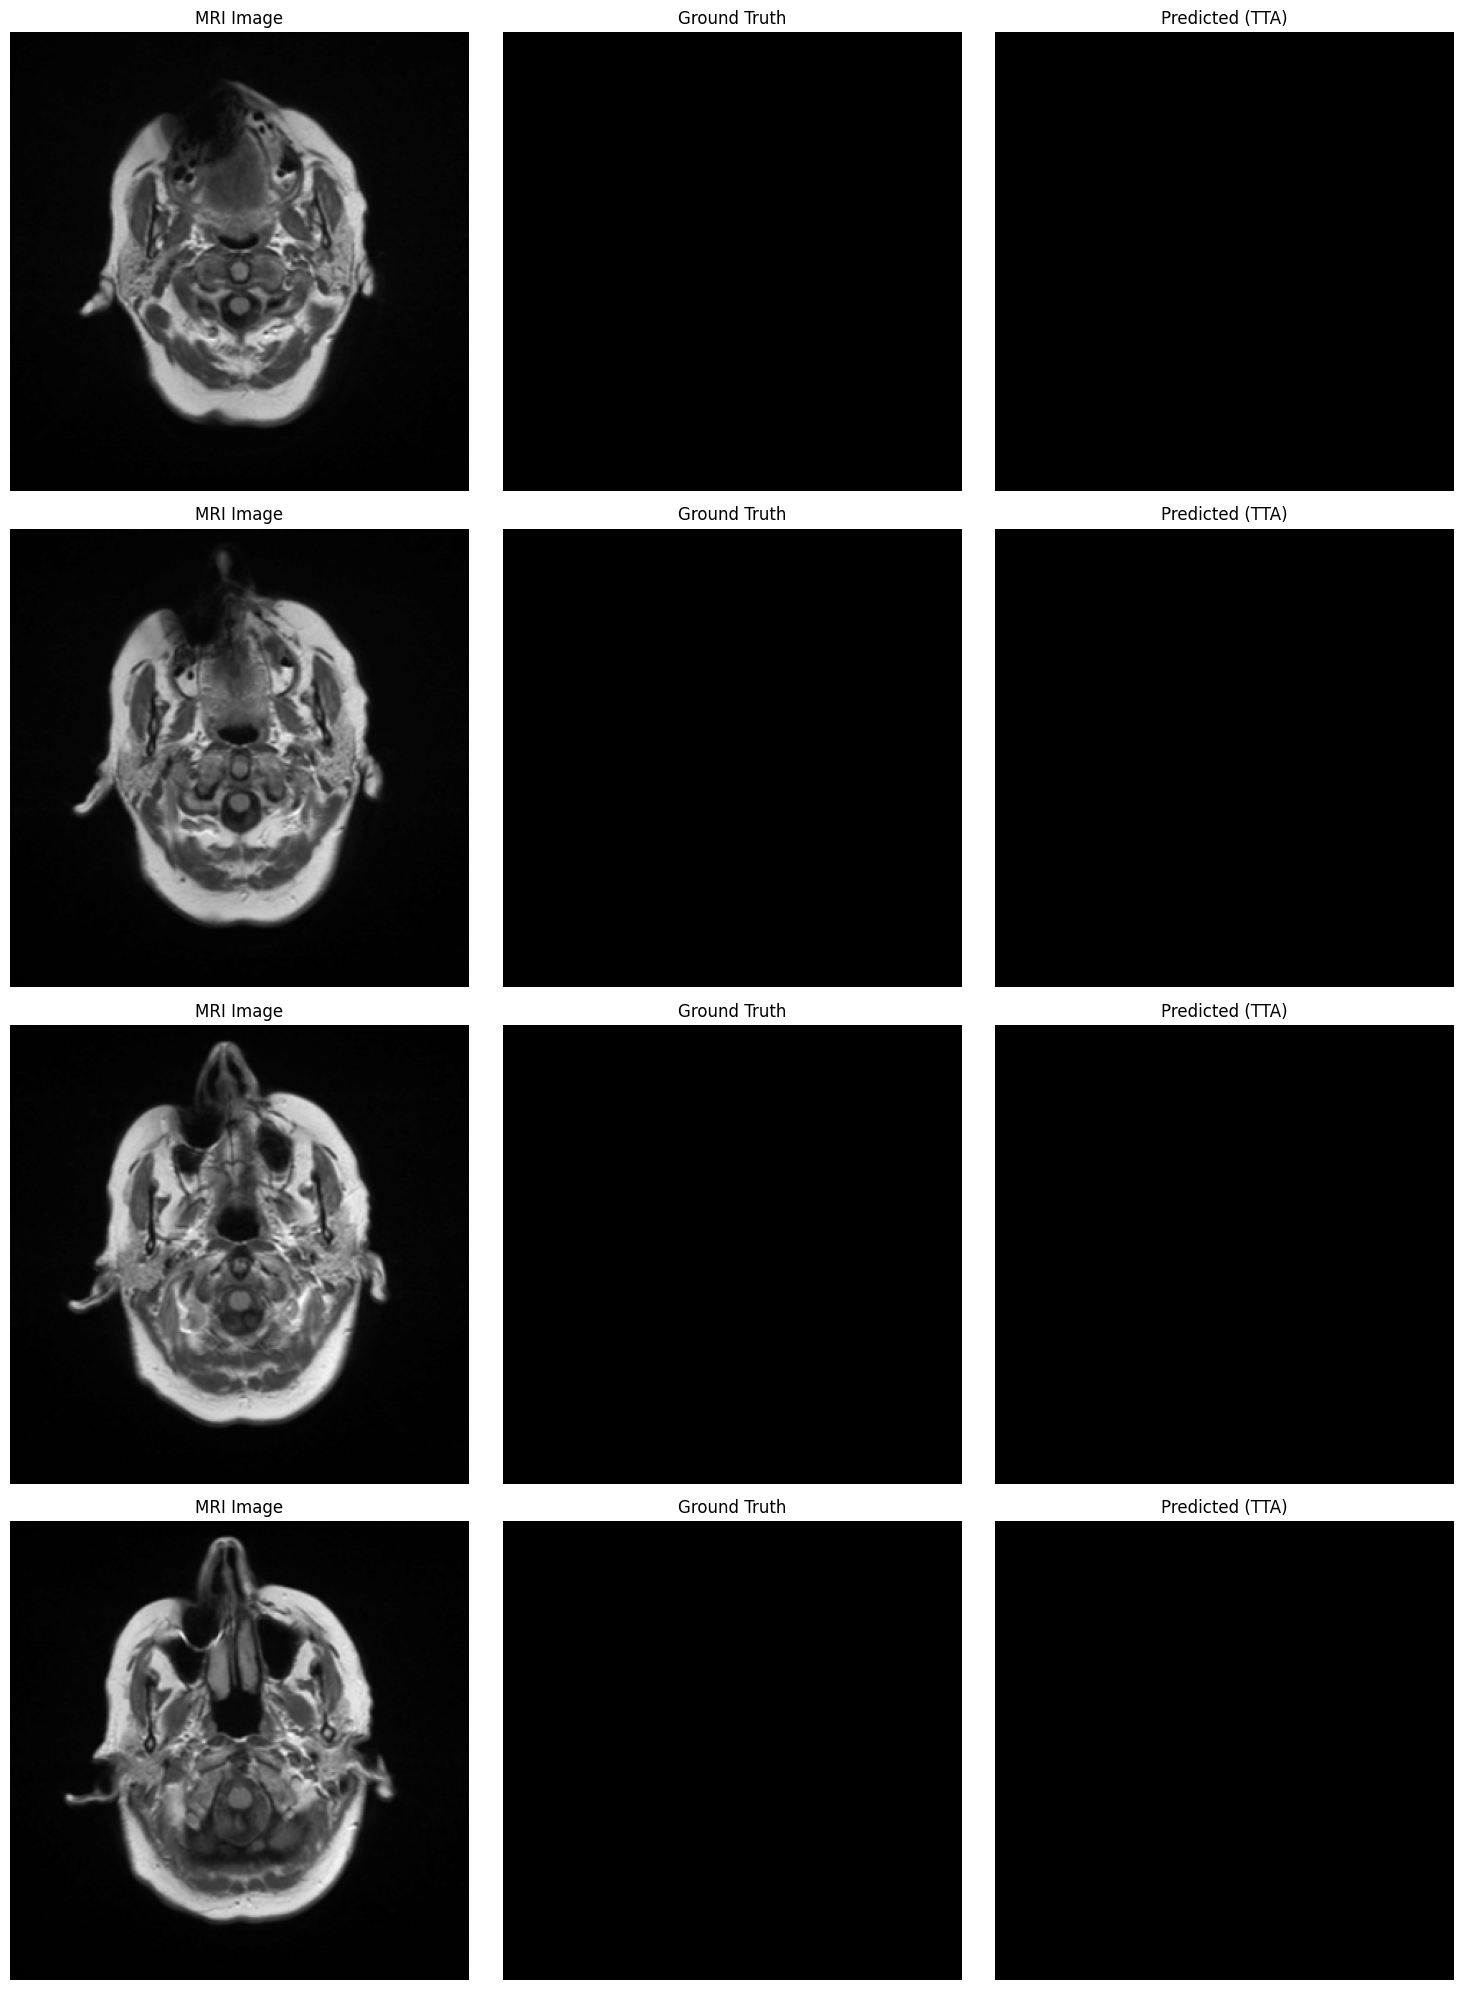

In [70]:
# PREDICTION VISUALIZATION

plt.figure(figsize=(15, 20))

for imgs, (masks, _, _) in test_ds.take(1):

    preds_tta = predict_with_tta(model, imgs)
    preds_binary = (preds_tta > 0.5).astype(np.float32)

    for i in range(4):

        # MRI Image
        plt.subplot(4, 3, i * 3 + 1)
        plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
        plt.title("MRI Image")
        plt.axis("off")

        # Ground Truth Mask
        plt.subplot(4, 3, i * 3 + 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        # Predicted Mask
        plt.subplot(4, 3, i * 3 + 3)
        plt.imshow(preds_binary[i].squeeze(), cmap="gray")
        plt.title("Predicted (TTA)")
        plt.axis("off")

plt.tight_layout()
plt.show()

# SAVE MODEL

In [71]:
model.save(MODEL_SAVE_PATH)

H5_PATH = MODEL_SAVE_PATH.replace(".keras", ".h5")
model.save(H5_PATH)

print("Model saved at:")
print("Keras :", MODEL_SAVE_PATH)
print("H5    :", H5_PATH)

Model saved at:
Keras : /content/drive/MyDrive/Project work/models/Segmentation/attention_resunet.keras
H5    : /content/drive/MyDrive/Project work/models/Segmentation/attention_resunet.h5


In [72]:
print("Evaluating on Test Set...")

results = model.evaluate(test_ds)

print("\nTest results:")
print(results)

Evaluating on Test Set...
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - d2_out_loss: 0.6837 - d3_out_loss: 0.6692 - final_out_dice_coefficient: 0.3590 - final_out_iou_score: 0.3065 - final_out_loss: 0.6680 - loss: 0.6713

Test results:
[0.5789312124252319, 0.5950961709022522, 0.5822903513908386, 0.58119136095047, 0.45219552516937256, 0.387113481760025]
